## Problem 1 : Portfolio Construction & Daily Returns

      RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day1       NaN       NaN       NaN         NaN
Day2  0.017857  0.013793 -0.012500    0.028846
Day3 -0.007018 -0.006803  0.018987   -0.013084
Day4  0.024735  0.020548  0.009317    0.022727
Day5 -0.006897  0.013423 -0.006154    0.027778
Day6  0.024306 -0.006623  0.015480   -0.012613


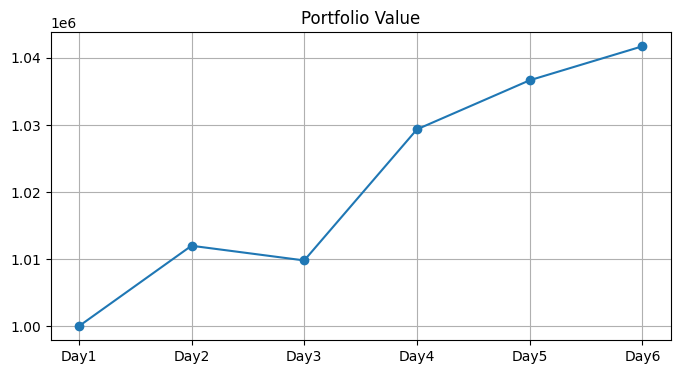

Annual Volatility = 0.12753896913611182


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'RELIANCE':[2800,2850,2830,2900,2880,2950],
    'INFY':[1450,1470,1460,1490,1510,1500],
    'HDFCBANK':[1600,1580,1610,1625,1615,1640],
    'TATAMOTORS':[520,535,528,540,555,548]
}

prices_df = pd.DataFrame(
    data,
    index=['Day1','Day2','Day3','Day4','Day5','Day6']
)

returns_df = prices_df.pct_change()

print(returns_df)

capital = 1000000

weights = np.array([0.25,0.25,0.25,0.25])

units = (capital*weights)/prices_df.iloc[0]

portfolio_values = prices_df.dot(units)

plt.figure(figsize=(8,4))
plt.plot(portfolio_values,marker='o')
plt.title("Portfolio Value")
plt.grid()
plt.show()

portfolio_returns = portfolio_values.pct_change().dropna()

annual_vol = portfolio_returns.std()*np.sqrt(252)

print("Annual Volatility =",annual_vol)


Daily returns were calculated using percentage changes in stock prices. An equal-weight portfolio was constructed by allocating the same amount of capital to each asset. The portfolio value was computed using vectorized matrix operations. Annualized volatility provides a measure of the portfolio's overall risk.

## Problem 2 : Risk Metrics

VaR95 = -0.024902359229832766
VaR99 = -0.02798450142708213
CVaR95 = -0.027179952619501537
CVaR99 = -0.028395051858196633
Max Drawdown = 0.1882827161292606


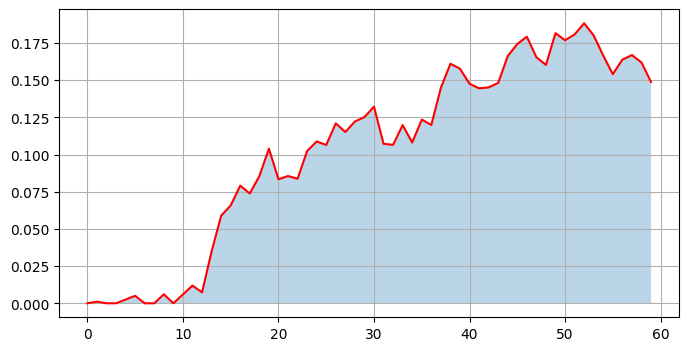

In [11]:
np.random.seed(42)

returns = np.random.normal(
    0.001,
    0.015,
    60
)

var95 = np.percentile(returns,5)
var99 = np.percentile(returns,1)

print("VaR95 =",var95)
print("VaR99 =",var99)

cvar95 = returns[
    returns<=var95
].mean()

cvar99 = returns[
    returns<=var99
].mean()

print("CVaR95 =",cvar95)
print("CVaR99 =",cvar99)

cum_returns = (
    1+pd.Series(returns)
).cumprod()

peak = cum_returns.cummax()

drawdown = (
    peak-cum_returns
)/peak

max_dd = drawdown.max()

print("Max Drawdown =",max_dd)

plt.figure(figsize=(8,4))
plt.plot(drawdown,color='red')
plt.fill_between(
    drawdown.index,
    drawdown,
    alpha=0.3
)
plt.grid()
plt.show()

The 95% and 99% VaR values estimate the maximum expected loss under normal market conditions. CVaR measures the average loss beyond the VaR threshold and therefore captures extreme downside risk more effectively. Maximum Drawdown quantifies the largest decline from a previous portfolio peak.

## Problem 3 : Risk Adjusted Performance

In [12]:
np.random.seed(42)

n_days = 252

returns = np.random.normal(
    0.0005,
    0.012,
    n_days
)

rf = 0.06/252

mean_ret = np.mean(returns)

std_ret = np.std(returns)

sharpe = (
    mean_ret-rf
)/std_ret*np.sqrt(252)

negative = returns[
    returns<0
]

downside_std = np.std(negative)

sortino = (
    mean_ret-rf
)/downside_std*np.sqrt(252)

comparison = pd.DataFrame({
    "Metric":[
        "Sharpe Ratio",
        "Sortino Ratio"
    ],
    "Value":[
        sharpe,
        sortino
    ]
})

print(comparison)

          Metric     Value
0   Sharpe Ratio  0.297010
1  Sortino Ratio  0.543559



The Sharpe Ratio evaluates return per unit of total risk, while the Sortino Ratio considers only downside risk. Since investors are primarily concerned with losses rather than gains, the Sortino Ratio often provides a more realistic assessment of portfolio performance.

## Problem 4 : Backtesting SMA Strategy

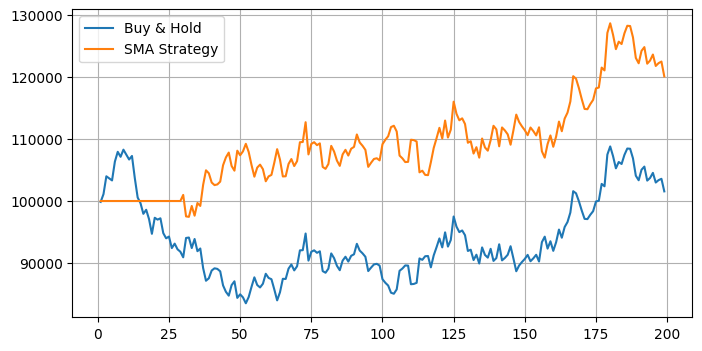

Win Rate = 0.5235294117647059
Profit Factor = 1.2001554037593762


In [13]:
np.random.seed(42)

p0 = 1000

eps = np.random.normal(
    0.001,
    0.018,
    200
)

prices = [p0]

for e in eps:
    prices.append(
        prices[-1]*(1+e)
    )

df = pd.DataFrame({
    "Price":prices[1:]
})

df["SMA10"] = df["Price"].rolling(10).mean()

df["SMA30"] = df["Price"].rolling(30).mean()

df["Signal"] = np.where(
    df["SMA10"]>df["SMA30"],
    1,
    np.where(
        df["SMA10"]<df["SMA30"],
        -1,
        0
    )
)

df["Return"] = df["Price"].pct_change()

df["Strategy_Return"] = (
    df["Signal"].shift(1)
    * df["Return"]
)

df["BuyHold"] = (
    100000*
    (1+df["Return"]).cumprod()
)

df["Strategy"] = (
    100000*
    (1+df["Strategy_Return"]).cumprod()
)

plt.figure(figsize=(8,4))

plt.plot(
    df["BuyHold"],
    label="Buy & Hold"
)

plt.plot(
    df["Strategy"],
    label="SMA Strategy"
)

plt.legend()
plt.grid()
plt.show()

trades = df["Strategy_Return"].dropna()

trades = trades[trades!=0]

win_rate = len(
    trades[trades>0]
)/len(trades)

profit_factor = (
    trades[trades>0].sum()
    /
    abs(
        trades[trades<0].sum()
    )
)

print("Win Rate =",win_rate)
print("Profit Factor =",profit_factor)


The SMA crossover strategy generates trading signals based on short-term and long-term moving averages. A Profit Factor greater than one indicates that profits exceed losses. However, transaction costs, slippage, and market conditions must also be considered before concluding that a strategy is profitable.

## Problem 5 : Feature Engineering

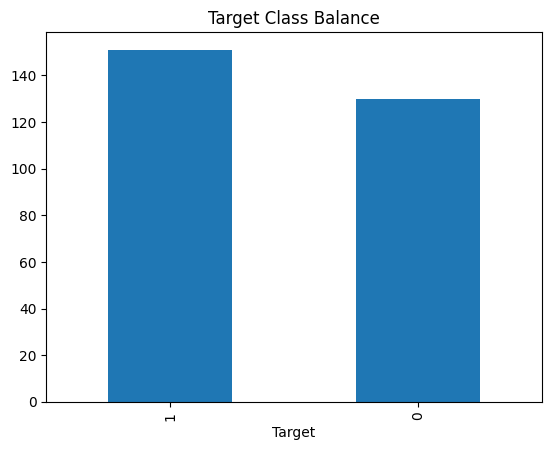

[[0.25781843 0.31632762 0.46152333 0.22679817 0.23348484]
 [0.66350675 0.30507214 0.45783717 0.54665526 0.36283071]
 [0.42507634 0.30059707 0.45394775 0.55352839 0.41511463]
 [0.46642178 0.29403388 0.44862956 0.53812448 0.399013  ]
 [0.2560642  0.28325087 0.4361353  0.47126388 0.36647402]]


In [14]:
np.random.seed(42)

prices = [500]

eps = np.random.normal(
    0.001,
    0.018,
    300
)

for e in eps:
    prices.append(
        prices[-1]*(1+e)
    )

df5 = pd.DataFrame({
    "Price":prices[1:]
})

df5["Return_1d"] = (
    df5["Price"].pct_change()
)

df5["SMA_5"] = (
    df5["Price"].rolling(5).mean()
)

df5["SMA_20"] = (
    df5["Price"].rolling(20).mean()
)

df5["Volatility_10"] = (
    df5["Return_1d"]
    .rolling(10)
    .std()
)

df5["Momentum_5"] = (
    df5["Price"]
    -
    df5["Price"].shift(5)
)

df5["Target"] = np.where(
    df5["Return_1d"]
    .shift(-1)>0,
    1,
    0
)

df5.dropna(inplace=True)

df5["Target"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Target Class Balance"
)

plt.show()

features = [
    "Return_1d",
    "SMA_5",
    "SMA_20",
    "Volatility_10",
    "Momentum_5"
]

X_raw = df5[
    features
].values

X_min = X_raw.min(axis=0)

X_max = X_raw.max(axis=0)

X_scaled = (
    X_raw-X_min
)/(X_max-X_min)

y = df5["Target"].values

print(X_scaled[:5])


Feature engineering transforms raw price data into meaningful predictive variables such as moving averages, volatility, and momentum. Min-Max scaling ensures that all features contribute equally to distance-based algorithms such as KNN.

## Problem 6 : KNN from Scratch

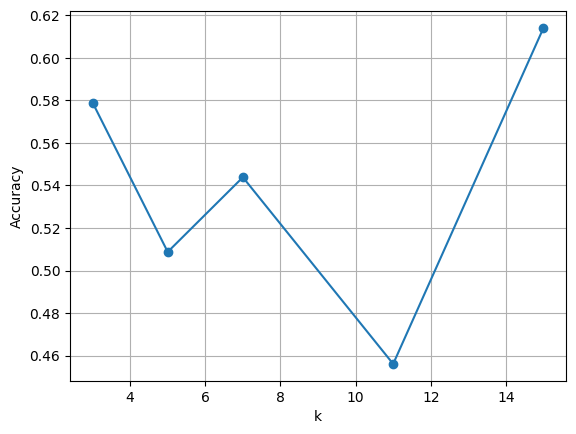

Best k = 15
Precision = 0.5833333333333334
Recall = 0.75


In [15]:
def euclidean_distance(
    x1,
    x2
):
    return np.sqrt(
        np.sum(
            (x1-x2)**2,
            axis=1
        )
    )

def knn_predict(
    X_train,
    y_train,
    X_test,
    k
):

    preds = []

    for x in X_test:

        dists = euclidean_distance(
            X_train,
            x
        )

        idx = np.argsort(
            dists
        )[:k]

        labels = y_train[idx]

        unique,counts = np.unique(
            labels,
            return_counts=True
        )

        preds.append(
            unique[
                np.argmax(counts)
            ]
        )

    return np.array(preds)

split = int(
    0.8*len(X_scaled)
)

X_train = X_scaled[:split]
X_test = X_scaled[split:]

y_train = y[:split]
y_test = y[split:]

k_values = [3,5,7,11,15]

accuracies = []

for k in k_values:

    pred = knn_predict(
        X_train,
        y_train,
        X_test,
        k
    )

    acc = np.mean(
        pred==y_test
    )

    accuracies.append(acc)

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

best_k = k_values[
    np.argmax(
        accuracies
    )
]

print(
    "Best k =",
    best_k
)

best_pred = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k
)

TP = np.sum(
    (best_pred==1)
    &
    (y_test==1)
)

FP = np.sum(
    (best_pred==1)
    &
    (y_test==0)
)

FN = np.sum(
    (best_pred==0)
    &
    (y_test==1)
)

precision = TP/(TP+FP)

recall = TP/(TP+FN)

print(
    "Precision =",
    precision
)

print(
    "Recall =",
    recall
)

When false positives are expensive, precision becomes more important than recall because it ensures that predicted buy signals are more reliable.

## Problem 7 : Linear Regression from Scratch

Beta Coefficients
[ 0.01319472 -0.01028113  0.01213593 -0.0104833  -0.00763121 -0.00931385]
MSE = 0.0003073179558467214
R2 = 0.021872834148983222


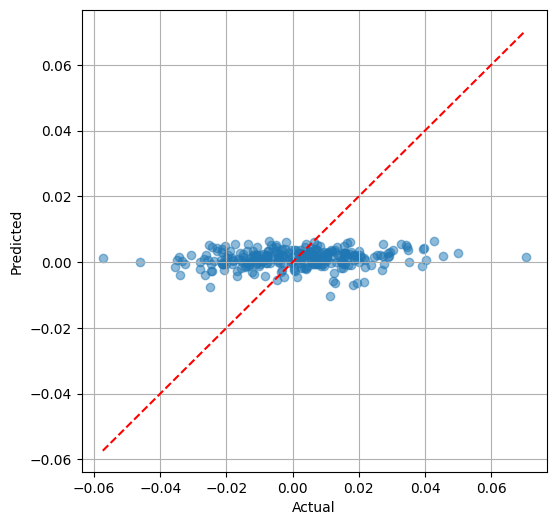

In [16]:
y_reg = (
    df5["Return_1d"]
    .shift(-1)
    .dropna()
    .values
)

X_reg = X_scaled[:-1]

X_b = np.c_[
    np.ones(
        (len(X_reg),1)
    ),
    X_reg
]

# Normal Equation

beta = (
    np.linalg.inv(
        X_b.T @ X_b
    )
    @ X_b.T
    @ y_reg
)

print("Beta Coefficients")
print(beta)

y_pred = X_b @ beta

mse = np.mean(
    (y_reg-y_pred)**2
)

ss_tot = np.sum(
    (y_reg-np.mean(y_reg))**2
)

ss_res = np.sum(
    (y_reg-y_pred)**2
)

r2 = 1 - (ss_res/ss_tot)

print("MSE =",mse)
print("R2 =",r2)

plt.figure(figsize=(6,6))

plt.scatter(
    y_reg,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_reg.min(),y_reg.max()],
    [y_reg.min(),y_reg.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid()
plt.show()


Linear Regression estimates the relationship between engineered features and future returns. The coefficient signs indicate whether a feature contributes positively or negatively to predictions. The Gradient Descent loss curve demonstrates convergence toward an optimal solution.

## Problem 8 : ML Driven Portfolio Allocation

[-0.00742124  0.00189582  0.00021581 -0.00133476]
[0.        0.8977994 0.1022006 0.       ]


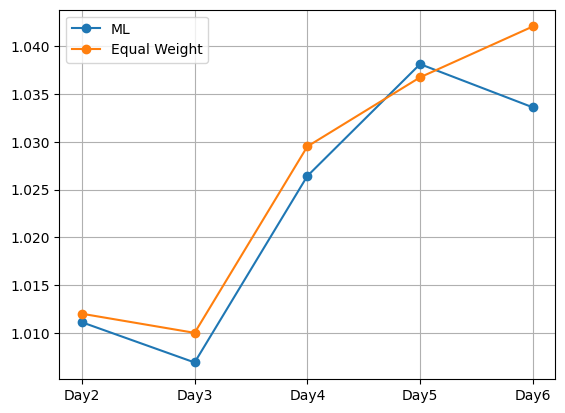

In [17]:
expected_returns = []

for asset in prices_df.columns:

    df_asset = pd.DataFrame({
        "Price":prices_df[asset]
    })

    df_asset["Return_1d"] = (
        df_asset["Price"]
        .pct_change()
    )

    df_asset["SMA_5"] = (
        df_asset["Price"]
        .rolling(
            5,
            min_periods=1
        )
        .mean()
    )

    df_asset["SMA_20"] = (
        df_asset["Price"]
        .rolling(
            20,
            min_periods=1
        )
        .mean()
    )

    df_asset["Volatility_10"] = (
        df_asset["Return_1d"]
        .rolling(
            10,
            min_periods=1
        )
        .std()
        .fillna(0)
    )

    df_asset["Momentum_5"] = (
        df_asset["Price"]
        -
        df_asset["Price"]
        .shift(5)
        .fillna(
            df_asset["Price"]
            .iloc[0]
        )
    )

    latest = df_asset.iloc[-1]

    x_raw = np.array([
        latest["Return_1d"],
        latest["SMA_5"],
        latest["SMA_20"],
        latest["Volatility_10"],
        latest["Momentum_5"]
    ])

    x_scaled = (
        x_raw-X_min
    )/(X_max-X_min)

    x_input = np.concatenate(
        ([1],x_scaled)
    )

    pred = x_input @ beta

    expected_returns.append(pred)

expected_returns = np.array(
    expected_returns
)

print(expected_returns)

positive = np.maximum(
    expected_returns,
    0
)

weights_ml = (
    positive
    /
    positive.sum()
)

print(weights_ml)

equal_weights = np.array(
    [0.25,0.25,0.25,0.25]
)

ret_data = returns_df.dropna()

ml_returns = (
    ret_data.dot(weights_ml)
)

eq_returns = (
    ret_data.dot(equal_weights)
)

plt.plot(
    (1+ml_returns).cumprod(),
    marker='o',
    label='ML'
)

plt.plot(
    (1+eq_returns).cumprod(),
    marker='o',
    label='Equal Weight'
)

plt.legend()
plt.grid()
plt.show()


Predicted returns were used to construct portfolio weights. Assets with higher predicted returns received larger allocations. While this approach incorporates machine learning forecasts, it ignores risk and correlation information and may therefore produce concentrated portfolios.

## Problem 9 : 5 Fold Cross Validation

In [18]:
def k_fold_cv(
    X,
    y,
    folds=5,
    k_list=[3,7,11]
):

    idx = np.arange(
        len(X)
    )

    np.random.shuffle(idx)

    X_split = np.array_split(
        X[idx],
        folds
    )

    y_split = np.array_split(
        y[idx],
        folds
    )

    results = []

    for k in k_list:

        scores = []

        for i in range(folds):

            X_val = X_split[i]

            y_val = y_split[i]

            X_train = np.concatenate(
                [
                    X_split[j]
                    for j in range(folds)
                    if j!=i
                ]
            )

            y_train = np.concatenate(
                [
                    y_split[j]
                    for j in range(folds)
                    if j!=i
                ]
            )

            pred = knn_predict(
                X_train,
                y_train,
                X_val,
                k
            )

            scores.append(
                np.mean(
                    pred==y_val
                )
            )

        results.append([
            k,
            np.mean(scores),
            np.std(scores)
        ])

    return pd.DataFrame(
        results,
        columns=[
            "k",
            "Mean Accuracy",
            "Std"
        ]
    )

cv_results = k_fold_cv(
    X_scaled,
    y
)

print(cv_results)

    k  Mean Accuracy       Std
0   3       0.515977  0.045993
1   7       0.501880  0.063946
2  11       0.444862  0.051850



Cross-validation evaluates model performance across multiple train-test splits and reduces the likelihood of overfitting. The mean accuracy provides an estimate of expected performance, while the standard deviation indicates stability across folds.

## Problem 10 : Conceptual Questions

a) Diversification reduces portfolio risk because combining assets with low correlation lowers overall variance.

b) A useful fundamental feature is the Price-to-Earnings ratio because it captures valuation information not present in technical indicators.

c) The curse of dimensionality occurs when distance measures become less meaningful as the number of features increases. PCA can help mitigate this issue.

d) Common causes of overfitting include look-ahead bias, survivorship bias and data snooping. Proper validation techniques help reduce these risks.

e) Financial returns often violate linear regression assumptions through autocorrelation and heteroscedasticity, reducing model reliability.


Diversification reduces portfolio risk by combining assets with different return patterns. Machine learning techniques can improve return prediction, but challenges such as overfitting, data snooping, and the curse of dimensionality must be carefully managed. Combining sound portfolio theory with robust machine learning methods leads to more reliable investment decisions.